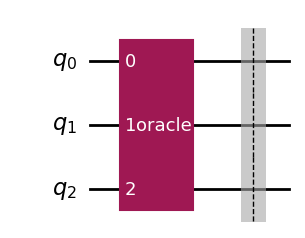

In [ ]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
#تعریف اوراکل
oracle_matrix = [
    [1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, -1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1],
]

oracle = QuantumCircuit(3)
oracle.unitary(oracle_matrix, qubits=[0, 1, 2], label='oracle')
oracle.barrier()
display(oracle.draw('mpl'))

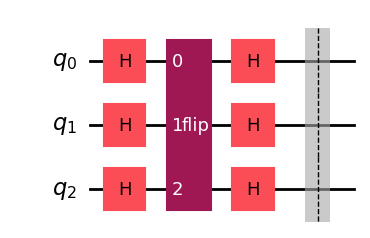

In [ ]:
#تعریف دیفیوزر
flip_matrix = [
    [ -1, 0, 0, 0, 0, 0, 0, 0],
    [ 0, 1, 0, 0, 0, 0, 0, 0],
    [ 0, 0, 1, 0, 0, 0, 0, 0],
    [ 0, 0, 0, 1, 0, 0, 0, 0],
    [ 0, 0, 0, 0, 1, 0, 0, 0],
    [ 0, 0, 0, 0, 0, 1, 0, 0],
    [ 0, 0, 0, 0, 0, 0, 1, 0],
    [ 0, 0, 0, 0, 0, 0, 0, 1],
]

flip = QuantumCircuit(3)
flip.unitary(flip_matrix, qubits=[0, 1, 2], label='flip')
h3 = QuantumCircuit(3)
h3.h([0, 1, 2])

diffuser = h3.compose(flip).compose(h3)
diffuser.barrier()
display(diffuser.draw('mpl'))

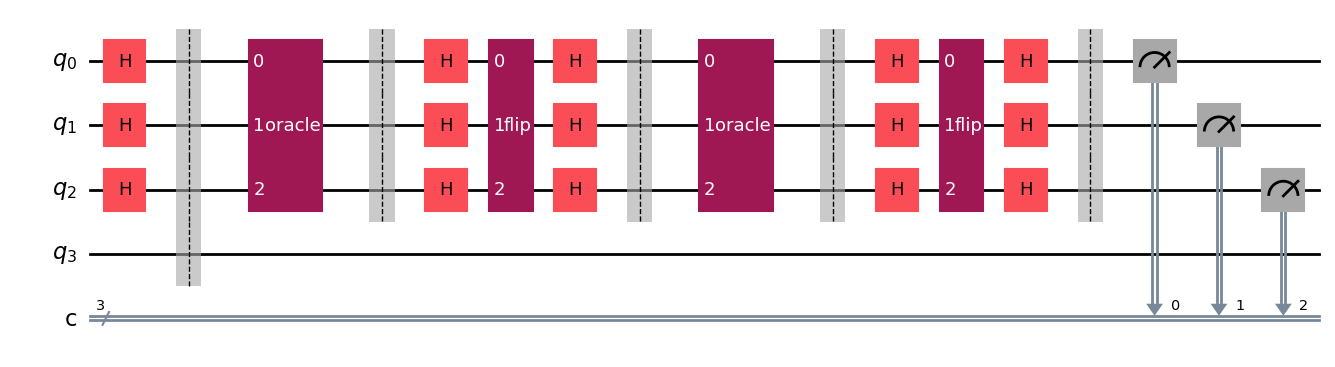

In [ ]:
#مدار الگوریتم گروور
grover_iterate = oracle.compose(diffuser)
circ = QuantumCircuit(4, 3)

circ.h([0, 1, 2])
circ.barrier()
circ = circ.compose(grover_iterate).compose(grover_iterate)
circ.measure([0, 1, 2], [0, 1, 2])
display(circ.draw('mpl'))

548ee4cd-5beb-402b-adaf-00b16ace9fd8
{'100': 943, '111': 13, '010': 11, '101': 8, '001': 6, '000': 6, '110': 6, '011': 7}


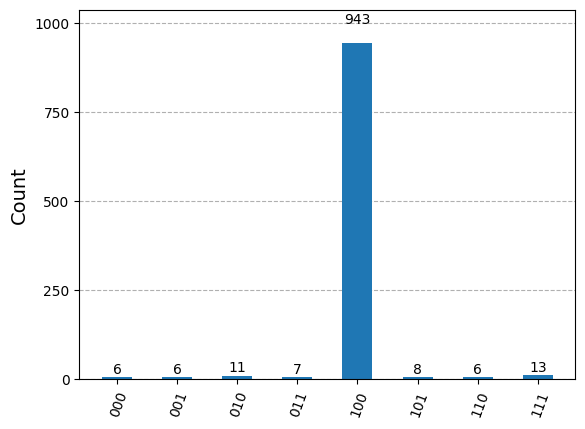

In [ ]:
#اجرای مدار
device = AerSimulator()
job = device.run(circ, backend = device, shots = 1000)
print(job.job_id())
result = job.result()
counts = result.get_counts(circ)
print(counts)
display(plot_histogram(counts))